In [2]:
import chess
import chess.pgn
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import numpy as np
import io

# Single game analysis
In this notebook we take the PGN string of a game and we unpack all the information that we can extract from it, then put the data in a dataframe.

## Load data

### Load data of a user

In [3]:
# the name of the user we're looking at
username = 'rugitodoleao_returns'

In [4]:
# or load results
with open('../data/player_data/{}.pkl'.format(username), 'rb') as f:
    data_raw = pickle.load(f)

### Load openings database

In [5]:
openings = pd.DataFrame()
for letter in ['a', 'b', 'c', 'd', 'e']:
    tmp = pd.read_csv('../data/chess-openings/dist/{}.tsv'.format(letter), sep='\t')
    openings = pd.concat((openings, tmp))

### Basic postprocessing: extract a single PGN file

In [6]:
# look inside the list of results and see if there are no games or there was an error code
data = []
for d in data_raw:
    try:
        if len(d['games']) > 0:
            data.append(d['games'])
    except KeyError:
        # this will typically happen if you asked for something weird such as the list of
        # games in the future
        continue

# create master dataframe
df = pd.concat([pd.DataFrame(d).set_index('url') for d in data])

In [7]:
# data from the API
game_api = df.iloc[219]

In [8]:
pgn = game_api.pgn
print(pgn)

[Event "Live Chess"]
[Site "Chess.com"]
[Date "2022.08.19"]
[Round "-"]
[White "rugitodoleao_returns"]
[Black "capedia"]
[Result "0-1"]
[CurrentPosition "8/8/8/5pk1/8/P1R2P2/6PP/6K1 w - -"]
[Timezone "UTC"]
[ECO "C60"]
[ECOUrl "https://www.chess.com/openings/Ruy-Lopez-Opening-Nurnberg-Variation"]
[UTCDate "2022.08.19"]
[UTCTime "14:36:57"]
[WhiteElo "789"]
[BlackElo "801"]
[TimeControl "60"]
[Termination "capedia won on time"]
[StartTime "14:36:57"]
[EndDate "2022.08.19"]
[EndTime "14:39:14"]
[Link "https://www.chess.com/game/live/54658652899"]

1. e4 {[%clk 0:01:00]} 1... e5 {[%clk 0:01:00]} 2. Nf3 {[%clk 0:00:58.6]} 2... Nc6 {[%clk 0:00:59.2]} 3. Bb5 {[%clk 0:00:56.9]} 3... f6 {[%clk 0:00:58.7]} 4. Nc3 {[%clk 0:00:55.2]} 4... Bc5 {[%clk 0:00:56.7]} 5. d4 {[%clk 0:00:53.9]} 5... exd4 {[%clk 0:00:55.5]} 6. Bxc6 {[%clk 0:00:51.5]} 6... bxc6 {[%clk 0:00:49.4]} 7. Nxd4 {[%clk 0:00:50.5]} 7... Bxd4 {[%clk 0:00:48.2]} 8. Qxd4 {[%clk 0:00:49.8]} 8... Ne7 {[%clk 0:00:46.7]} 9. O-O {[%clk 0:00

## Game preprocessing

In [9]:
def get_usercolor(game, username):
    
    # figure out the color of the user
    for color in ['white', 'black']:
        
        if game.headers.get(color.capitalize()) == username:
            return color

In [10]:
# we can use this to extract all the information we need
game = chess.pgn.read_game(io.StringIO(pgn))

# get user color
usercolor = get_usercolor(game, username)

# init game board
board = game.board()

# iterate through the moves
game_data = []
for i, move in enumerate(game.mainline_moves()):
    
    # get move number
    move_number = i//2 + 1
    
    # black or white
    if i%2 == 0:
        color =  'white'
    else:
        color = 'black'
    
    # get start square and end square and determine the piece that was moved
    start_square, end_square = move.uci()[:2], move.uci()[2:]
    piece = board.piece_at(chess.parse_square(start_square)).symbol().upper()
    
    # get the move in SAN notation
    san = board.san(move)
    
    # get move in UCI notation
    uci = board.uci(move)
    
    # push the move to the board
    board.push(move)
    
    # put together all the data that we have
    this_move_data = (i, move_number, color, piece, uci, san, board.epd(), board.fen())
    
    # append the data to this move
    game_data.append(this_move_data)
    
game_data = pd.DataFrame(game_data, columns=['i', 'move_number', 'color', 'piece', 'uci', 'san', 'epd', 'fen'])

# init the classification column
game_data['classification'] = 'unknown'

## Move classification

### Book moves

In [11]:
# the end of the book openings is defined as the last board position where we see that there
# is a correspondance to a board position from the database
last_book_move = game_data.merge(openings, on='epd').tail(1).iloc[0]

In [12]:
# set the book move classification info
game_data.loc[game_data.i <= last_book_move.i, 'classification'] = 'book'

### Engine evaluation of the moves
To proceed in the classification of the moves, the first thing we do is we ask the engine to evaluate the positions.

In [13]:
# init the engine
engine = chess.engine.SimpleEngine.popen_uci("/home/rcortini/soft/stockfish_15.1_linux_x64/src/stockfish")

In [14]:
def get_info(
    fen,
    engine,
    depth = 10):
    
    # set a chess.Board with the supplied FEN string
    b = chess.Board(fen=fen)
    
    # return the game analysis info
    info = engine.analyse(b, chess.engine.Limit(depth=depth))
    return info

In [15]:
%%time
# depth of the engine
depth = 10

# calculate score: remember, this means that we are 
# evaluating the score of the board AFTER the move.
# For the classification of the move, we need to therefore
# compare the score BEFORE the current move. For the
# first move there is no need to compute the score at
# the beginning, because all the first moves are book moves.
game_data['info'] = game_data.fen.apply(lambda fen : get_info(fen, engine, depth=depth))

CPU times: user 197 ms, sys: 13.7 ms, total: 210 ms
Wall time: 1.47 s


### Best moves
We can now determine whether the moves of the user were the best moves or not. The `info` column of the dataframe contain the information on what was the best move in the position. To explain how we're going to do that, let's look first at the `game_data` dataframe:

In [18]:
game_data['info'].iloc[0]

{'string': 'NNUE evaluation using nn-ad9b42354671.nnue enabled',
 'depth': 10,
 'seldepth': 13,
 'multipv': 1,
 'score': PovScore(Cp(-35), BLACK),
 'nodes': 39060,
 'nps': 406875,
 'hashfull': 12,
 'tbhits': 0,
 'time': 0.096,
 'pv': [Move.from_uci('c7c5'),
  Move.from_uci('c2c3'),
  Move.from_uci('g8f6'),
  Move.from_uci('e4e5'),
  Move.from_uci('f6d5'),
  Move.from_uci('g1f3'),
  Move.from_uci('e7e6')]}

In [16]:
game_data.head()

,i,move_number,color,piece,uci,san,epd,fen,classification,info
0,0,1,white,P,e2e4,e4,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,unknown,{'string': 'NNUE evaluation using nn-ad9b42354...
1,1,1,black,P,e7e5,e5,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,unknown,{'string': 'NNUE evaluation using nn-ad9b42354...
2,2,2,white,N,g1f3,Nf3,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,unknown,{'string': 'NNUE evaluation using nn-ad9b42354...
3,3,2,black,N,b8c6,Nc6,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,unknown,{'string': 'NNUE evaluation using nn-ad9b42354...
4,4,3,white,B,f1b5,Bb5,r1bqkbnr/pppp1ppp/2n5/1B2p3/4P3/5N2/PPPP1PPP/R...,r1bqkbnr/pppp1ppp/2n5/1B2p3/4P3/5N2/PPPP1PPP/R...,unknown,{'string': 'NNUE evaluation using nn-ad9b42354...


The columns of the `game_data` dataframe are the following represent:

- **i**: the computer-friendly move number (i.e. the number of half-moves minus one - because it starts at zero.)
- **move_number**: the move number in chess notation
- **piece**: the symbol of the piece that was moved
- **color**: the color of the user *that made the move*
- **san**: the move made, in SAN notation
- **epd** and **fen**: the EPD and FEN strings of the position *after the move*
- **info**: the evaluation of the board *after the move*

If we want to evaluate the move in question, we must look at the **line before** the current one. In fact, the `info` of the line before contains the best moves of the next turn, which is the turn of the current line.

In [12]:
game_data

,i,move_number,color,piece,uci,san,epd,fen,classification
0,0,1,white,P,e2e4,e4,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,unknown
1,1,1,black,P,e7e5,e5,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,unknown
2,2,2,white,N,g1f3,Nf3,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,unknown
3,3,2,black,N,b8c6,Nc6,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,unknown
4,4,3,white,B,f1b5,Bb5,r1bqkbnr/pppp1ppp/2n5/1B2p3/4P3/5N2/PPPP1PPP/R...,r1bqkbnr/pppp1ppp/2n5/1B2p3/4P3/5N2/PPPP1PPP/R...,unknown
...,...,...,...,...,...,...,...,...,...
65,65,33,black,K,g4g5,Kg5,8/8/8/5pk1/2R5/P7/5PPP/6K1 w - -,8/8/8/5pk1/2R5/P7/5PPP/6K1 w - - 6 34,unknown
66,66,34,white,R,c4c3,Rc3,8/8/8/5pk1/8/P1R5/5PPP/6K1 b - -,8/8/8/5pk1/8/P1R5/5PPP/6K1 b - - 7 34,unknown
67,67,34,black,K,g5g4,Kg4,8/8/8/5p2/6k1/P1R5/5PPP/6K1 w - -,8/8/8/5p2/6k1/P1R5/5PPP/6K1 w - - 8 35,unknown
68,68,35,white,P,f2f3,f3+,8/8/8/5p2/6k1/P1R2P2/6PP/6K1 b - -,8/8/8/5p2/6k1/P1R2P2/6PP/6K1 b - - 0 35,unknown


In [16]:
for row, move in game_data.iterrows():
    
    # first, we must skip the book moves
    if move.classification == 'book':
        continue
        
    # Compare the UCI of the move to the best move of the 
    # position. That info is stored in the `ìnfo` in the `pv`
    # list. The first element of that list is the best move.
    # The data structure returned is a chess.Move object, of
    # which we can access the `uci` function to get the move in
    # UCI notation
    if move.uci == game_data.iloc[row-1]['info']['pv'][0].uci():
        game_data.loc[game_data.i == move.i, 'classification'] = 'best'
        
game_data.classification.value_counts()

unknown    43
best       21
book        6
Name: classification, dtype: int64

To classify the other moves, we can use a combination of resources.

First, according to the official website, there is a [move classification table](https://support.chess.com/article/2965-how-are-moves-classified-what-is-a-blunder-or-brilliant-and-etc), as follows:

In [17]:
classification_matrix_str = \
"""Classification	Lower Limit	Upper Limit
Best	0.00	0.00
Excellent	0.00	0.02
Good	0.02	0.05
Inaccuracy	0.05	0.10
Mistake	0.10	0.20
Blunder	0.20	1.00"""
tmp = [r.split('\t') for r in classification_matrix_str.split('\n')]
classification_matrix = pd.DataFrame(tmp[1:], columns=tmp[0]).set_index('Classification').astype(float)*100
classification_matrix

,Lower Limit,Upper Limit
Classification,,
Best,0.0,0.0
Excellent,0.0,2.0
Good,2.0,5.0
Inaccuracy,5.0,10.0
Mistake,10.0,20.0
Blunder,20.0,100.0


This classification does not take into consideration special moves, classified as "brilliant", "great move", or "miss". We won't take those into consideration in a first round of analysis.

We therefore first need to calculate the win probability and accuracy of each move.

## Win probability and accuracy

We use the idea from [Lichess's page on the accuracy metric.](https://lichess.org/page/accuracy)

First, we calculate the `win_pct` of the move: it represents the probability of winning the game, based on the value of the centipawns. This is represented by the following function:

$$
w_{\%} = 50 + 50\left(\frac{2}{1 + \exp{-\lambda C_p}} - 1\right)
$$
where $\lambda = 0.00368208$.

The function looks like this:

In [18]:
def win_pct_f(centipawns):
    return 50 + 50 * (2 / (1 + np.exp(-0.00368208*centipawns)) - 1)

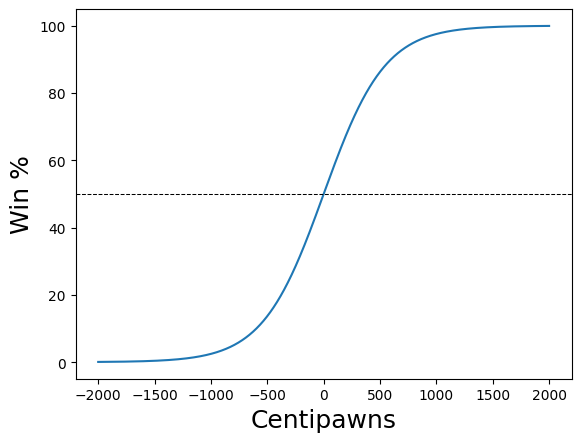

In [19]:
centipawns = np.arange(-2000, 2000)
win_pct = win_pct_f(centipawns)
plt.plot(centipawns, win_pct)
plt.xlabel("Centipawns", fontsize=18)
plt.ylabel("Win %", fontsize=18)
plt.axhline(y=50, linestyle='--', color='k', linewidth=0.75)
plt.show()

As you can see, the curve represents the probability of winning the game based on the value of the centipawns. In this sense one can notice that there is a large difference of losing 500 centipawns when you're close to zero, than when you're very much winning or losing.

In [34]:
def calculate_cp(
    score : chess.engine.PovScore,
):
    return score.relative.score(mate_score=5000)    

# first, we calculate the centipawn score for each of the moves.
# Remember: the info represents the board AFTER the move, so the centipawn
# value in this case will be relative to the color of the next turn
game_data['cp'] = game_data['info'].apply(lambda info : calculate_cp(info['score']))

Then we can evaluate the accuracy by calculating the following function:

$$
a = K_1 \exp{-\gamma (w_{b} - w_{a})} - K_2
$$
where $K_1 = 103.1668$, $K_2 = 3.1669$, and $\gamma = 0.04354$. The symbols represent:

- $a$ is the accuracy
- $w_a$ is the win percentage after the move
- $w_b$ is the win percentage before the move.

In [21]:
def accuracy_f(
    winPercentBefore,
    winPercentAfter
):  
    # calculate the accuracy function
    accuracy = 103.1668 * np.exp(-0.04354 * (winPercentBefore - winPercentAfter)) - 3.1669
    
    # first, check that the values make sense
    if accuracy > 100:
        return 100.
    if accuracy < 0.:
        return 0.
    
    # then return the value now bounded between [0, 100]
    return accuracy

The `accuracy` of the move then is calculated for each of the moves. We must pay a lot of attention with turns and signs: at every move, the `info` of the move represents the score after the move. Then, the score is represented from the point of view of the next player! Therefore, to calculate the win% after the move, we take that value and change sign to the centipawn evaluation. The win% before the move is represented by the win% value of the score corresponding to the line before the move.

Since we now calculate the win% before and after the move, we can also classify the moves.

In [35]:
accuracy = pd.Series(index=game_data.index, dtype=float, name='accuracy')
move_classification = pd.Series(index=game_data.index, dtype=str, name='classification_chess_lichess')
cp_loss = pd.Series(index=game_data.index, dtype=float, name='cp_loss')
for i in range(len(game_data)):
    
    # if it's the first move, assign a zero value to the centipawns
    if i == 0:
        cpBefore = 0.
    else:
        cpBefore = game_data.iloc[i-1].cp
        
    # change sign to the value corresponding to this move
    cpAfter = -game_data.iloc[i].cp
        
    # calculate accuracy: NOTE here that we don't just
    # blindly calculate the win% before and after the move, because
    # otherwise this would mean that the moves done when the game is
    # practically won would almost always count as best or excellent moves,
    # with close to 100% accuracy
    a = accuracy_f(50., win_pct_f(cpAfter-cpBefore))
    
    # calculate the delta
    d = win_pct_f(cpAfter)-win_pct_f(cpBefore)
    
    # establish the move classes
    if d >= 0.:
        mc = 'best'
    elif d < 0. and d > -2.0:
        mc = 'excellent'
    elif d < -2.0 and d > -5.0:
        mc = 'good'
    elif d < -5.0 and d > -10.0:
        mc = 'inaccuracy'
    elif d < -10.0 and d > -20.0:
        mc = 'mistake'
    else:
        mc = 'blunder'
        
    print("Move {}: cpBefore = {:.1f} cpAfter = {:.1f},  d = {:.2f}, a = {:.2f}, {}".format(\
          i, cpBefore, cpAfter, d, a, mc))
    
    accuracy[i] = a
    move_classification[i] = mc
    cp_loss[i] = cpAfter-cpBefore

# put in the info on the move classification
mask = (game_data.classification != 'book') & (game_data.classification != 'best')
game_data.loc[mask, 'classification'] = move_classification[mask]

# put the info on the accuracy
game_data['accuracy'] = accuracy
game_data['cp_loss'] = cp_loss

Move 0: cpBefore = 0.0 cpAfter = 40.0,  d = 3.68, a = 100.00, best
Move 1: cpBefore = -40.0 cpAfter = -30.0,  d = 0.92, a = 100.00, best
Move 2: cpBefore = 30.0 cpAfter = 24.0,  d = -0.55, a = 97.55, excellent
Move 3: cpBefore = -24.0 cpAfter = -25.0,  d = -0.09, a = 99.59, excellent
Move 4: cpBefore = 25.0 cpAfter = 33.0,  d = 0.73, a = 100.00, best
Move 5: cpBefore = -33.0 cpAfter = -84.0,  d = -4.64, a = 80.98, good
Move 6: cpBefore = 84.0 cpAfter = 67.0,  d = -1.53, a = 93.21, excellent
Move 7: cpBefore = -67.0 cpAfter = -60.0,  d = 0.64, a = 100.00, best
Move 8: cpBefore = 60.0 cpAfter = -40.0,  d = -9.18, a = 66.24, inaccuracy
Move 9: cpBefore = 40.0 cpAfter = -36.0,  d = -6.98, a = 73.06, inaccuracy
Move 10: cpBefore = 36.0 cpAfter = -86.0,  d = -11.16, a = 60.61, mistake
Move 11: cpBefore = 86.0 cpAfter = -64.0,  d = -13.72, a = 54.23, mistake
Move 12: cpBefore = 64.0 cpAfter = 60.0,  d = -0.36, a = 98.36, excellent
Move 13: cpBefore = -60.0 cpAfter = -123.0,  d = -5.63, a = 77

## User report

In [36]:
# filter out the user data
user_game_data = game_data.query('color == @usercolor')

In [37]:
user_game_data[['move_number', 'piece', 'san', 'cp', 'accuracy', 'classification']]

,move_number,piece,san,cp,accuracy,classification
0,1,P,e4,-40,100.000000,book
2,2,N,Nf3,-24,97.548670,book
4,3,B,Bb5,-33,100.000000,book
6,4,N,Nc3,-67,93.206891,excellent
8,5,P,d4,40,66.242364,inaccuracy
10,6,B,Bxc6,86,60.612985,mistake
12,7,N,Nxd4,-60,98.359170,best
14,8,Q,Qxd4,-104,92.438299,best
16,9,K,O-O,-47,79.981614,good
18,10,P,exd5,-90,78.673077,inaccuracy


In [38]:
user_game_data.classification.value_counts()

best          15
excellent      5
good           5
book           3
inaccuracy     3
mistake        2
blunder        2
Name: classification, dtype: int64

In [39]:
user_game_data.query('classification != "book"').accuracy.mean()

74.98690444022928

In [33]:
user_game_data.query('classification != "book"').groupby('piece').accuracy.mean()

piece
B    71.586694
K    79.981614
N    90.640310
P    60.079718
Q    76.047674
R    77.388049
Name: accuracy, dtype: float64

In [47]:
user_game_data.query('classification != "book" & piece == "B"')[['i', 'move_number', 'san', 'classification', 'cp', 'cp_loss', 'accuracy', 'info']].iloc[-1]['info']

{'string': 'NNUE evaluation using nn-ad9b42354671.nnue enabled',
 'depth': 20,
 'seldepth': 20,
 'multipv': 1,
 'score': PovScore(Cp(-2920), BLACK),
 'nodes': 2130935,
 'nps': 1477763,
 'hashfull': 492,
 'tbhits': 0,
 'time': 1.442,
 'pv': [Move.from_uci('g5h6'),
  Move.from_uci('a3a4'),
  Move.from_uci('h6g5'),
  Move.from_uci('a4a5'),
  Move.from_uci('g5f4'),
  Move.from_uci('a5a6'),
  Move.from_uci('f4e4'),
  Move.from_uci('h2h4'),
  Move.from_uci('e4d3'),
  Move.from_uci('a6a7'),
  Move.from_uci('f5f4'),
  Move.from_uci('h4h5'),
  Move.from_uci('d3d2'),
  Move.from_uci('h5h6'),
  Move.from_uci('f4f3'),
  Move.from_uci('g2g4'),
  Move.from_uci('d2e2'),
  Move.from_uci('h6h7'),
  Move.from_uci('e2d2'),
  Move.from_uci('g4g5')]}

In [49]:
game_data.iloc[57]['info']

{'string': 'NNUE evaluation using nn-ad9b42354671.nnue enabled',
 'depth': 20,
 'seldepth': 25,
 'multipv': 1,
 'score': PovScore(Cp(+3313), WHITE),
 'nodes': 97594,
 'nps': 1682655,
 'hashfull': 38,
 'tbhits': 0,
 'time': 0.058,
 'pv': [Move.from_uci('a3a4'),
  Move.from_uci('g5g4'),
  Move.from_uci('g7h6'),
  Move.from_uci('g4h5'),
  Move.from_uci('h6d2'),
  Move.from_uci('h5g6'),
  Move.from_uci('a4a5'),
  Move.from_uci('g6f6'),
  Move.from_uci('a5a6'),
  Move.from_uci('f6e6'),
  Move.from_uci('a6a7'),
  Move.from_uci('e6e5'),
  Move.from_uci('c7c5'),
  Move.from_uci('e5e6'),
  Move.from_uci('d2c3'),
  Move.from_uci('f5f4'),
  Move.from_uci('f2f3'),
  Move.from_uci('e6e7'),
  Move.from_uci('c3e5')]}